In [ ]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [ ]:
#fish_data를 2차원 리스트로 정리, 정답지(target) 생성

fish_data = [[l,w] for l,w in zip(fish_length, fish_weight)]
fish_target = [1]*35 + [0]*14


In [ ]:
#확인

print(fish_data)
print(fish_target)


[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
#knn 소환

from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()


In [ ]:
print(fish_data[4])


[29.0, 430.0]


In [ ]:
#trainset를 35개의 데이터까지
train_input = fish_data[:35]
train_target = fish_target[:35]

#test를 35개부터 끝의 데이터까지
test_input = fish_data[35:]
test_target = fish_target[35:]

In [ ]:
#knn 성능 테스트 다시 -> 결과는 0.0, 도미만 학습했는데 빙어를 물어봤으니 자연스레 틀림.

kn.fit(train_input, train_target)
kn.score(test_input, test_target)


0.0

In [ ]:
#샘플링 편향 해결
#input_arr 입력 리스트와, target_arr 정답 리스트 생성


import numpy as np

input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

In [ ]:
#1부터 49 숫자 담긴 리스트 생성 후 섞어주기
np.random.seed(42)
index = np.arange(49)
np.random.shuffle(index)

print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [ ]:
#랜덤한 번호를 부여해 도미와 빙어 데이터 섞어주기, 이제 [:35]는 13 45....37까지를 의미

train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]


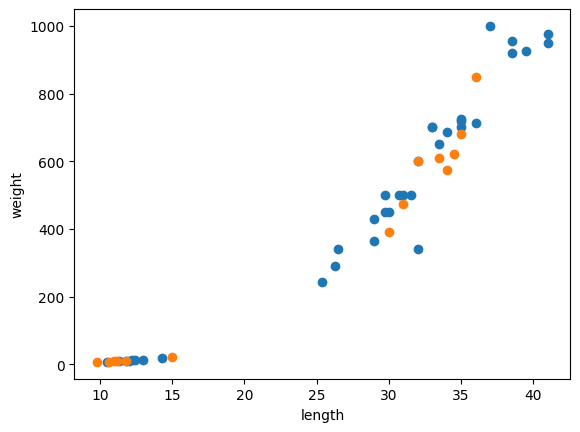

In [ ]:
#훈련 세트와 테스트 세트 내의 도미와 빙어가 잘 섞였다.
import matplotlib.pyplot as plt

plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(test_input[:,0], test_input[:,1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
#정확도 확인

kn.fit(train_input, train_target)
kn.score(test_input, test_target)


1.0

In [ ]:
#테스트 세트의 길이와 무게를 2차원 배열로 생성
fish_data = np.column_stack((fish_length, fish_weight))
print(fish_data[:5])


[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]


In [ ]:
#타겟 세트(정답 세트) 생성
fish_target = np.concatenate((np.ones(35), np.zeros(14)))
print(fish_target)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [ ]:
#trian:36개, test:13개로 나눔, input은 2차원 배열이라서 (,2)이고 target은 1차원 배열이라 (.)
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state = 42)

print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)

(36, 2) (13, 2)
(36,) (13,)


In [ ]:
#실제 도미와 빙어 비율과 좀 다름, 조정을 해주자.
print(test_target)

[1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
#stratify 매개변수 전달 -> target비율에 맞춰 데이터를 나눠줌.

train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42)

In [ ]:
#비슷한 비율로 조정됨
print(test_target)

[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
#다시 학습
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [ ]:
#여전히 도미를 빙어로 분류함, 1차시 때와 같은 결과

print(kn.predict([[25,150]]))

[0.]


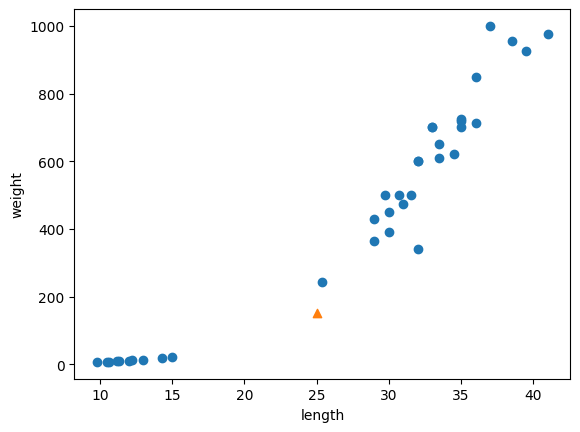

In [ ]:
#가까운 sample 5개가 도미인 모습
import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker = '^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
distances, indexes = kn.kneighbors([[25,150]])

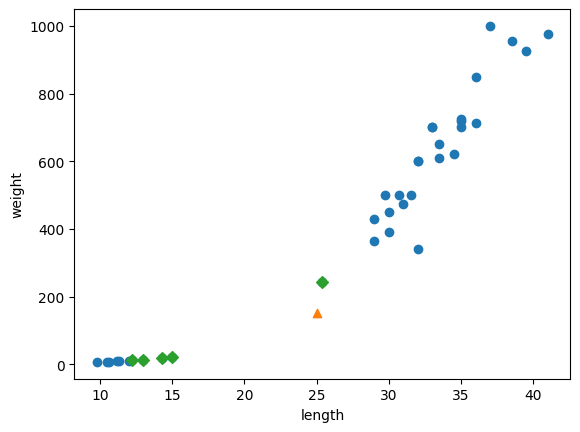

In [ ]:
#빙어 데이터를 더 근처라고 표현하는 모습.
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker = '^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker = 'D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
#가장 가까운 데이터와의 거리는 92, 가장 먼 데이터와의 거리는 138
#대충 보기에도 먼 데이터는 훨씬 더 차이가 나보이는데 왜 46밖에 차이가 안나지?
print(train_input[indexes])
print(train_target[indexes])
print(distances)

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 14.3  19.7]
  [ 13.   12.2]
  [ 12.2  12.2]]]
[[1. 0. 0. 0. 0.]]
[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]]


In [ ]:
#스케일링 작업 >> 데이터 전처리는 스케일링을 포함한 큰 개념
#가장 많이 쓰는 표준점수로 스케일링을 해보자

mean = np.mean(train_input, axis=0) #평균
std = np.std(train_input, axis =0) #표준편차

print(mean,std)


[ 27.29722222 454.09722222] [  9.98244253 323.29893931]


In [ ]:
train_scaled = (train_input - mean) / std #표준점수


[-0.23012627 -0.94060693]


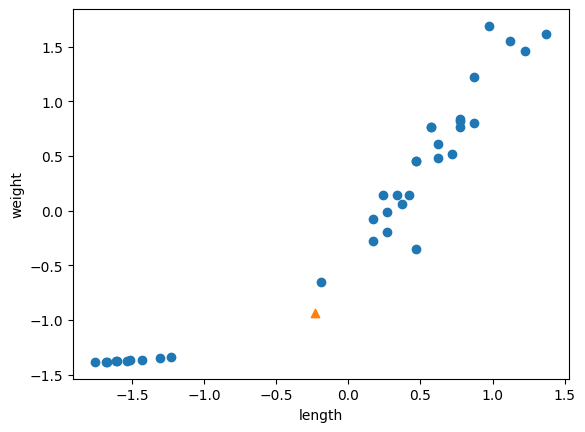

In [ ]:
new = ([25,150] - mean) / std #새로운 샘플도 표준 점수로 변환

#산점도 그래프 표시

print(new)
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker = '^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
#스케일링 후에는 정상적으로 도미라고 판단함, 정확도도 100%

kn.fit(train_scaled, train_target)
test_scaled = (test_input - mean)/std
kn.score(test_scaled, test_target)
print(kn.predict([new]))
print(kn.score(test_scaled, test_target))

[1.]
1.0


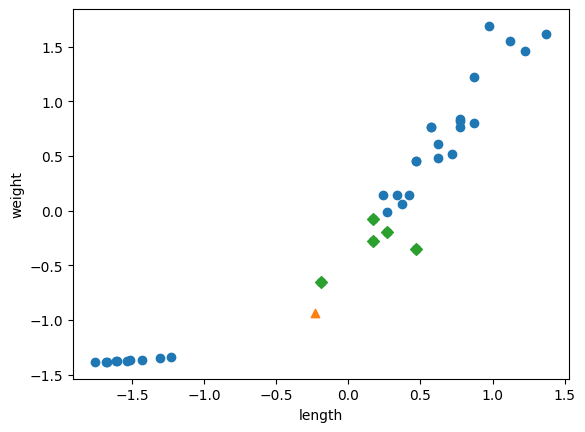

In [ ]:
#new데이터와의 거리를 표시하니 아까와 달리 도미 데이터와 가깝게 설정된 걸 알 수 있음.
#눈으로 본 결과와 같아짐!
distances,indexes=kn.kneighbors([new])
plt.scatter(train_scaled[:,0],train_scaled[:,1])
plt.scatter(new[0],new[1],marker='^')
plt.scatter(train_scaled[indexes,0],train_scaled[indexes,1],marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
#과제
# 1. test_size 파라미터를 사용해 7:3으로 데이터를 분리해봐요.

train_input_7, test_input_7, train_target_7, test_target_7 = train_test_split(fish_data, fish_target, test_size=0.3, random_state=42)

In [ ]:
# Q2. 5:5로 분리해봐요
train_input_5, test_input_5, train_target_5, test_target_5 = train_test_split(fish_data, fish_target, test_size=0.5, random_state=42)

In [ ]:
# Q3. 9:1로 분리해봐요
train_input_9, test_input_9, train_target_9, test_target_9 = train_test_split(fish_data, fish_target, test_size=0.1, random_state=42)

In [ ]:
# Q4. 위의 1, 2, 3번의 분리 결과로 KNN 알고리즘의 정확도를 테스트 해봐요
kn = KNeighborsClassifier()
kn.fit(train_input_7, train_target_7)
kn.score(test_input_7, test_target_7)

1.0

In [ ]:
kn.fit(train_input_5, train_target_5)
kn.score(test_input_5, test_target_5)

1.0

In [ ]:
kn.fit(train_input_9, train_target_9)
kn.score(test_input_9, test_target_9)

1.0

In [ ]:
# 7:3 분리 결과 확인 (hint: len() 사용)

length_test_input_7 =len(test_input_7)
print(length_test_input_7)

15


In [ ]:
# 5:5 분리 결과 확인 (hint: len() 사용)

length_test_input_5 = len(test_input_5)
print(length_test_input_5)

25


In [ ]:
# 9:1 분리 결과 확인 (hint: len() 사용)

length_test_input_9 = len(test_input_9)
print(length_test_input_9)

5


In [ ]:
# 과제: Numpy 없이 순수 파이썬으로 표준점수 스케일링하기
# 7:3 비율로 나눈 훈련세트와 테스트 세트를 사용

lengths = [fish[0] for fish in train_input_7]
weights = [fish[1] for fish in train_input_7]
n = len(train_input_7)

print(lengths)

# Q1. sum() 함수를 이용해 길이와 무게의 평균을 구하세요.

mean_length = sum(lengths) / n
mean_weight = sum(weights) / n

[np.float64(29.7), np.float64(11.3), np.float64(11.8), np.float64(13.0), np.float64(32.0), np.float64(30.7), np.float64(33.0), np.float64(35.0), np.float64(41.0), np.float64(38.5), np.float64(25.4), np.float64(12.0), np.float64(39.5), np.float64(29.7), np.float64(37.0), np.float64(31.0), np.float64(10.5), np.float64(26.3), np.float64(34.0), np.float64(26.5), np.float64(10.6), np.float64(9.8), np.float64(35.0), np.float64(11.2), np.float64(31.0), np.float64(34.5), np.float64(33.5), np.float64(15.0), np.float64(34.0), np.float64(30.0), np.float64(11.8), np.float64(32.0), np.float64(36.0), np.float64(11.0)]


In [ ]:
# Q2. for문과 ** 연산자를 이용해 길이와 무게의 분산을 구하세요.
# 힌트: 분산 = (각 데이터 - 평균)의 제곱의 합 / 데이터 개수

var_length = 0
var_weight = 0

for i in range(n):
    var_length += (lengths[i] - mean_length)**2
    var_weight += (weights[i] - mean_weight)**2

var_length = var_length / n
var_weight = var_weight / n

In [ ]:
# Q3. 분산에 제곱근을 씌워 표준편차를 구하세요. ( ** 0.5 이용 )
std_length = var_length**0.5
std_weight = var_weight**0.5

In [ ]:
# Q4. 구해진 평균과 표준편차를 이용해 train_input의 모든 데이터를 스케일링하여 새로운 리스트에 담으세요.
train_scaled_manual = []
for lengths, weights in train_input:
  scaled_l = (lengths - mean_length) / std_length
  scaled_w = (weights - mean_weight) / std_weight

  train_scaled_manual.append([scaled_l, scaled_w])


In [ ]:
# 확인용 평균과 표준편차 출력
print(f"수동 계산 평균: {mean_length:.2f}, {mean_weight:.2f}")
print(f"수동 계산 표준편차: {std_length:.2f}, {std_weight:.2f}")
print(f"스케일링된 첫 데이터: {train_scaled_manual[0]}")

수동 계산 평균: 25.98, 418.77
수동 계산 표준편차: 10.47, 330.82
스케일링된 첫 데이터: [np.float64(0.35524721025467154), np.float64(0.24553693777514005)]


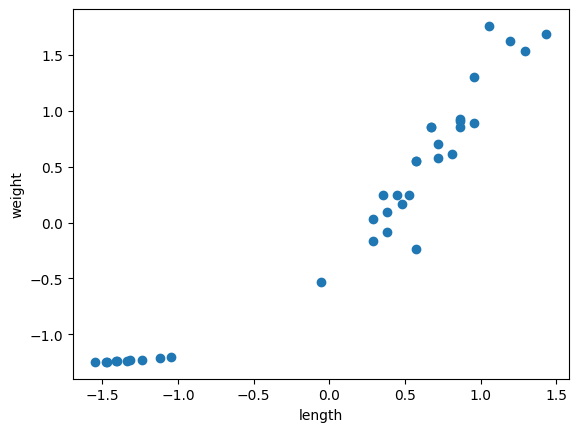

In [59]:
import matplotlib.pyplot as plt

# 1. 스케일링된 2차원 리스트에서 길이(X축)와 무게(Y축) 데이터 분리하기
scaled_lengths = [item[0] for item in train_scaled_manual]
scaled_weights = [item[1] for item in train_scaled_manual]

# 2. 산점도 그리기
plt.scatter(scaled_lengths, scaled_weights)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()